### **1. Import Library**

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

### **2. Load Dataset** 

In [4]:
import os
import numpy as np
import joblib

data_path = "data/processed"
models_path = "models"
os.makedirs(models_path, exist_ok=True)

X_train_scaled = np.load(os.path.join(data_path, "X_train_final_scaled.npy"))
y_train_final  = np.load(os.path.join(data_path, "y_train_final.npy"))
X_test_scaled  = np.load(os.path.join(data_path, "X_test_scaled.npy"))
y_test         = np.load(os.path.join(data_path, "y_test.npy"))

# Split Train → Validation
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_final,
    test_size=0.2, stratify=y_train_final, random_state=42
)

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_num = le.fit_transform(y_tr)
y_val_num   = le.transform(y_val)
y_test_num  = le.transform(y_test)

# Simpan LabelEncoder
label_encoder_file = os.path.join(models_path, "label_encoder.pkl")
joblib.dump(le, label_encoder_file)

print("Mapping kelas numerik:")
for i, cls in enumerate(le.classes_):
    print(f"{i} -> {cls}")

Mapping kelas numerik:
0 -> black-bellied_whistling_duck
1 -> canadian_goose
2 -> greylag_goose
3 -> pink-footed_goose
4 -> white-faced_whistling_duck


### **Feature Selection**

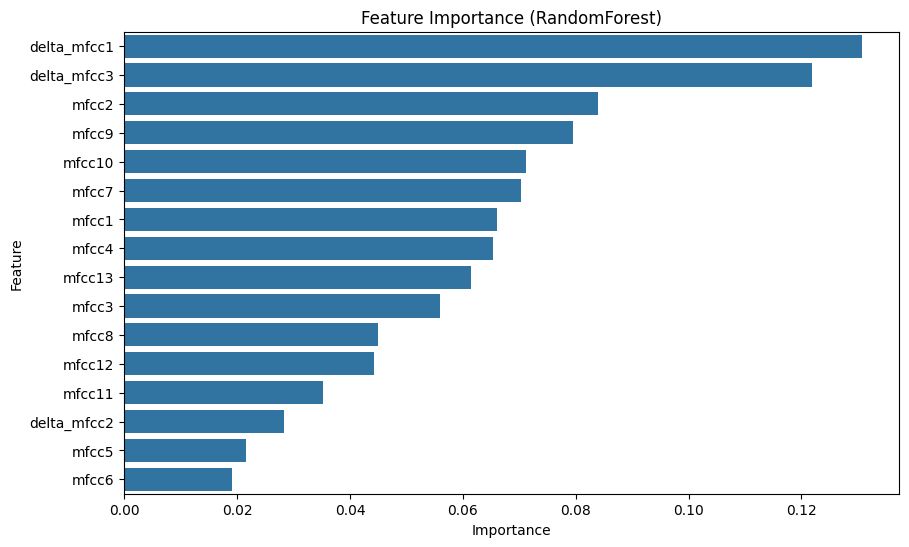

Fitur yang dipilih (13): ['delta_mfcc1', 'delta_mfcc3', 'mfcc2', 'mfcc9', 'mfcc10', 'mfcc7', 'mfcc1', 'mfcc4', 'mfcc13', 'mfcc3', 'mfcc8', 'mfcc12', 'mfcc11']


In [5]:
# Feature names (dari hasil ekstraksi audio)
feature_names = [
    "mfcc1","mfcc2","mfcc3","mfcc4","mfcc5","mfcc6","mfcc7",
    "mfcc8","mfcc9","mfcc10","mfcc11","mfcc12","mfcc13",
    "delta_mfcc1","delta_mfcc2","delta_mfcc3","delta_mfcc4","delta_mfcc5",
    "zcr","rms","centroid","spectral_rolloff","spectral_bandwidth"
]

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
rf_selector = RandomForestClassifier(n_estimators=500, random_state=42)
rf_selector.fit(X_tr, y_train_num)

importances = rf_selector.feature_importances_
feat_imp_df = pd.DataFrame({"Feature": feature_names[:X_tr.shape[1]], "Importance": importances})
feat_imp_df = feat_imp_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df)
plt.title("Feature Importance (RandomForest)")
plt.show()

# Ambil top 13 fitur
selected_features = feat_imp_df.head(13)["Feature"].tolist()
selected_idx = [feature_names.index(f) for f in selected_features]

X_tr_sel  = X_tr[:, selected_idx]
X_val_sel = X_val[:, selected_idx]
X_test_sel = X_test_scaled[:, selected_idx]

print(f"Fitur yang dipilih ({len(selected_features)}): {selected_features}")


### **4. Training Models** 

In [6]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest ---
rf_params = {'n_estimators':[500], 'max_depth':[20], 'min_samples_split':[2,3]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=skf, scoring='f1_macro')
rf_grid.fit(X_tr_sel, y_train_num)
rf_best = rf_grid.best_estimator_

# --- XGBoost ---
xgb_params = {'n_estimators':[500], 'max_depth':[7], 'learning_rate':[0.05], 'subsample':[0.9], 'colsample_bytree':[0.9]}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, cv=skf, scoring='f1_macro')
xgb_grid.fit(X_tr_sel, y_train_num)
xgb_best = xgb_grid.best_estimator_

# --- KNN ---
scaler_knn = StandardScaler()
X_tr_knn  = scaler_knn.fit_transform(X_tr_sel)
X_val_knn = scaler_knn.transform(X_val_sel)
X_test_knn = scaler_knn.transform(X_test_sel)

knn_params = {'n_neighbors':[5], 'weights':['distance'], 'p':[2]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=skf, scoring='f1_macro')
knn_grid.fit(X_tr_knn, y_train_num)
knn_best = knn_grid.best_estimator_

# --- Ensemble Soft Voting ---
ensemble = VotingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_best), ('knn', knn_best)],
    voting='soft'
)
ensemble_pipeline = make_pipeline(StandardScaler(), ensemble)
ensemble_pipeline.fit(X_tr_sel, y_train_num)


,steps,"[('standardscaler', ...), ('votingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None


### **5. Evaluasi pada Validation Set** 

In [10]:
from sklearn.metrics import f1_score

y_val_pred_rf  = rf_best.predict(X_val_sel)
y_val_pred_xgb = xgb_best.predict(X_val_sel)
y_val_pred_knn = knn_best.predict(X_val_knn)
y_val_pred_ens = ensemble_pipeline.predict(X_val_sel)

val_scores = {
    'RandomForest': f1_score(y_val_num, y_val_pred_rf, average='macro'),
    'XGBoost': f1_score(y_val_num, y_val_pred_xgb, average='macro'),
    'KNN': f1_score(y_val_num, y_val_pred_knn, average='macro'),
    'Ensemble': f1_score(y_val_num, y_val_pred_ens, average='macro')
}

best_name = max(val_scores, key=val_scores.get)
best_model = {
    'RandomForest': rf_best,
    'XGBoost': xgb_best,
    'KNN': knn_best,
    'Ensemble': ensemble_pipeline
}[best_name]

print(f"Best model berdasarkan F1-score validation: {best_name}")

import joblib

# Simpan model terbaik ke file
best_model_file = f"models/{best_name.lower()}_best_model.pkl"
joblib.dump(best_model, best_model_file)


Best model berdasarkan F1-score validation: KNN


['models/knn_best_model.pkl']

### **6. Evaluasi pada Test Set** 

Test Accuracy: 0.5400
Test F1-score (macro): 0.5451

Classification Report:
                              precision    recall  f1-score   support

black-bellied_whistling_duck       1.00      0.50      0.67        10
              canadian_goose       0.46      0.60      0.52        10
               greylag_goose       0.33      0.50      0.40        10
           pink-footed_goose       0.50      0.30      0.38        10
  white-faced_whistling_duck       0.73      0.80      0.76        10

                    accuracy                           0.54        50
                   macro avg       0.60      0.54      0.55        50
                weighted avg       0.60      0.54      0.55        50



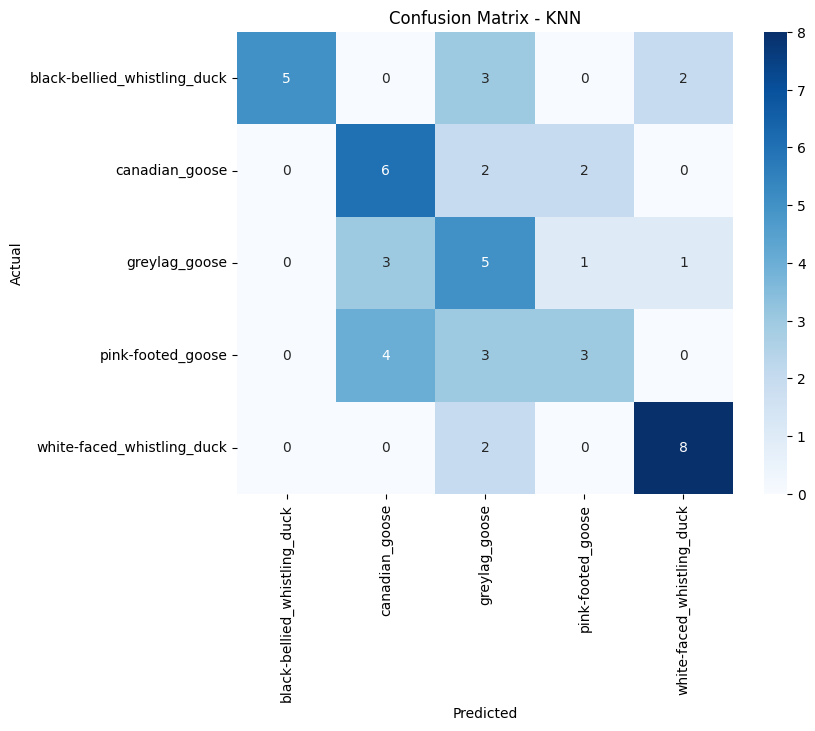

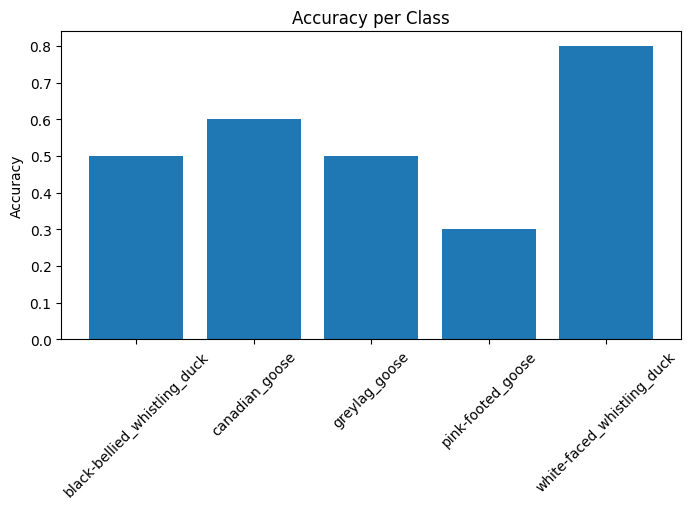


Accuracy per class:
black-bellied_whistling_duck: 0.50
canadian_goose: 0.60
greylag_goose: 0.50
pink-footed_goose: 0.30
white-faced_whistling_duck: 0.80

Apakah model berhasil (Success)? NO


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_test_final = X_test_knn if best_name=='KNN' else X_test_sel
y_test_pred = best_model.predict(X_test_final)

acc_test = accuracy_score(y_test_num, y_test_pred)
f1_test = f1_score(y_test_num, y_test_pred, average='macro')

print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test F1-score (macro): {f1_test:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_num, y_test_pred, target_names=le.classes_))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_num, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

# Accuracy per class
class_acc = {cls: accuracy_score(y_test_num[y_test_num==i], y_test_pred[y_test_num==i]) 
             for i, cls in enumerate(le.classes_)}
plt.figure(figsize=(8,4))
plt.bar(class_acc.keys(), class_acc.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Accuracy per Class")
plt.show()

print("\nAccuracy per class:")
for cls, acc_cls in class_acc.items():
    print(f"{cls}: {acc_cls:.2f}")

success = (acc_test >= 0.85) and (f1_test >= 0.80)
print(f"\nApakah model berhasil (Success)? {'YES' if success else 'NO'}")

### **7. Feature Importance** 

Top 13 fitur berdasarkan Random Forest:
   Feature  Importance
1    mfcc2    0.135439
0    mfcc1    0.135165
2    mfcc3    0.089869
4    mfcc5    0.073824
5    mfcc6    0.071654
3    mfcc4    0.071507
6    mfcc7    0.071458
7    mfcc8    0.070250
8    mfcc9    0.067956
9   mfcc10    0.066360
10  mfcc11    0.051714
11  mfcc12    0.048097
12  mfcc13    0.046706


C:\Users\Fujitsu\AppData\Local\Temp\ipykernel_9208\1955901356.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_features, palette="viridis")


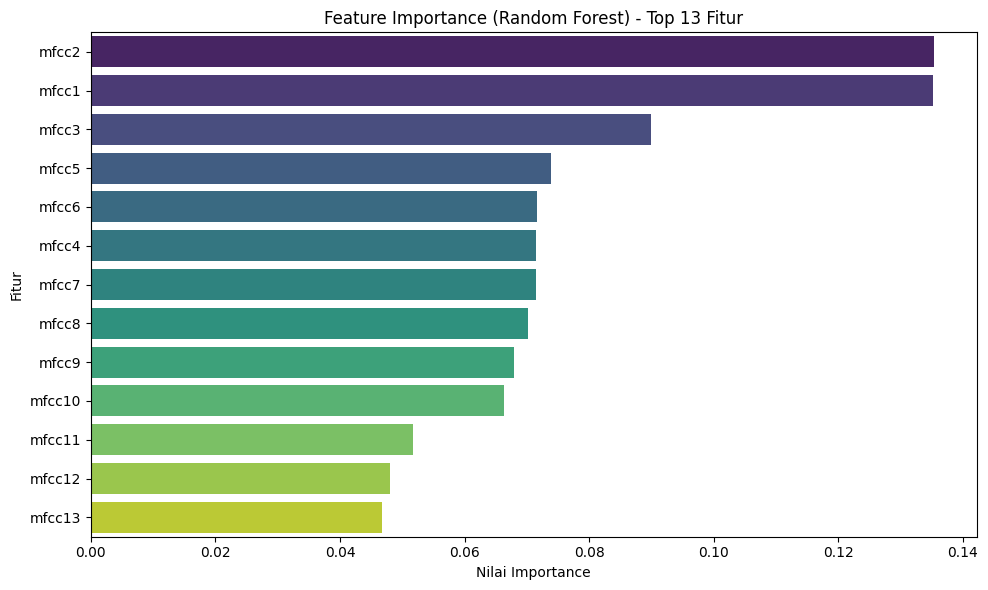

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# --- Pastikan X_tr_sel dan y_train_num sudah ada ---
# X_tr_sel = fitur training yang sudah dipilih / scaled
# y_train_num = label numerik training

# --- Definisikan nama fitur asli ---
feature_names = [
    "mfcc1","mfcc2","mfcc3","mfcc4","mfcc5","mfcc6","mfcc7",
    "mfcc8","mfcc9","mfcc10","mfcc11","mfcc12","mfcc13",
    "delta_mfcc1","delta_mfcc2","delta_mfcc3","delta_mfcc4","delta_mfcc5",
    "zcr","rms","centroid","spectral_rolloff","spectral_bandwidth"
]

# --- Bangun Random Forest untuk Feature Importance ---
rf_selector = RandomForestClassifier(n_estimators=500, random_state=42)
rf_selector.fit(X_tr_sel, y_train_num)

# --- Ambil nilai feature importance ---
importances = rf_selector.feature_importances_

# --- Buat DataFrame untuk mempermudah visualisasi ---
feat_imp_df = pd.DataFrame({
    "Feature": feature_names[:X_tr_sel.shape[1]],  # pastikan jumlah sama
    "Importance": importances
}).sort_values("Importance", ascending=False)

# --- Top 13 fitur ---
top_features = feat_imp_df.head(13)
print("Top 13 fitur berdasarkan Random Forest:")
print(top_features)

# --- Visualisasi Feature Importance ---
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top_features, palette="viridis")
plt.title("Feature Importance (Random Forest) - Top 13 Fitur")
plt.xlabel("Nilai Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()


## Analisis Feature Importance

Setelah membangun **Random Forest** pada data training, kita bisa melihat fitur-fitur mana yang paling berkontribusi terhadap prediksi spesies burung. Random Forest memberikan nilai *feature importance* untuk setiap fitur, yang menunjukkan seberapa besar pengaruh fitur tersebut dalam membagi data pada setiap *decision tree*.  

Berikut adalah **top 13 fitur** berdasarkan *feature importance*:  
- MFCCs (`mfcc1–mfcc13`) menangkap karakteristik frekuensi spektral dari suara burung, sehingga banyak fitur MFCC muncul di top 13.  
- Fitur *delta_mfcc* menangkap perubahan MFCC dari waktu ke waktu, berguna untuk mendeteksi pola dinamis pada audio.  
- Fitur lain seperti `zcr`, `rms`, `centroid`, `spectral_rolloff`, dan `spectral_bandwidth` menangkap informasi ritme, energi, dan distribusi frekuensi, yang membantu membedakan burung yang mirip.  

### Interpretasi Grafik Feature Importance
- Grafik di bawah menunjukkan kontribusi relatif masing-masing fitur.  
- Fitur di bagian atas memiliki pengaruh lebih besar terhadap model.  
- Misalnya, jika `mfcc3` dan `mfcc5` paling tinggi, berarti karakteristik frekuensi yang mereka wakili paling signifikan untuk membedakan spesies.  

> Dengan memilih **top 13 fitur**, kita melakukan *dimensionality reduction* sambil mempertahankan fitur paling relevan. Ini membantu:
> - Mengurangi kompleksitas model
> - Mempercepat training
> - Meminimalkan risiko *overfitting*
